In [305]:
import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d
import torch

import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)

COLORS = plot_settings.colors()

import_reload()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
GP_FIT = GP.GP_process()

In [306]:
RUN_ID = '1305'

DT = 1
Q0 = 17921.57581 
L0 = 14.37325  # cell length [1e-5m]
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  3.0,
    's':  0.1
    }


LIMS = {
    'R0': (1e-3, 0.1),
    'R1': (5e-3, 0.1),
    'C1': (1e2, 2.5e4),
    'k':  (0.1, 10.0),
    's':  (0.01, 1.0)
    }

VARIABLES = ['R0', 'R1', 'C1']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'µm'
    }
N_VAR = len(VARIABLES)

In [307]:
# Alternaitvely load model as GLOBAL
# model_name = '0513_1037_b4_combo_1.0__DC_V-static_no_R0_F-static_R0c_C1c_3.04min_16h_500eps.pt'
#model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
model_name = '0513_1037_b4_combo_1.0__DC_V-static_no_R0_F-static_R0c_C1c_3.04min_16h_500eps.pt'

BAT_MODEL, ckpt = load_nn_model(model_name)
history, CONFIG, N_HIDDEN, EPOCHS = load_checkpoint(ckpt)
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    print('Predicting k with NN')
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def NN_prediction(traj, model = BAT_MODEL, config = CONFIG, ret_elem = False):
    res = predict_np(model,config,traj)
    if ret_elem:
        return res['V'], res['soc'], res['R0'], res['R1'], res['C1'], res['k']
    else:
        return res['V'], res['soc']
    
def NN_prediction_F(traj, model = BAT_MODEL, config = CONFIG, ret_elem = False):
    res = predict_np(model,config,traj)
    if ret_elem:
        return res['V'], res['soc'], res['R0'], res['R1'], res['C1'], res['k'], res['s']
    else:
        return res['Fr'], res['soc'], res['s']

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'static_no_R0', 'style_F': 'static'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
s constrained to [0.0, 0.5] 1e-5 m  (static sNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


RuntimeError: Error(s) in loading state_dict for BatteryECMM:
	Missing key(s) in state_dict: "black_net.net.0.weight", "black_net.net.0.bias", "black_net.net.2.weight", "black_net.net.2.bias", "black_net.net.4.weight", "black_net.net.4.bias". 

## ECM solver module

In [ ]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1', 'R0', 's']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()*0.75)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['R0'], expressions['R1'], expressions['C1'], expressions['k'],  expressions['s']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)



R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr, 'numpy')
sdot_func = sp.lambdify(('x0', 'x1', 'x2', 'X3'), s_expr, 'numpy')
k_func = sp.lambdify(('C', 'd', 'soc'), k_expr, 'numpy')
R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr, 'numpy')
C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr, 'numpy')


Loading symbolic regression results for RUN_ID: 1305


In [211]:
display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))

display(Math(f'\\LARGE f_{{R_0}}(x_0,x_1,x_2) = {sp.latex(R0_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))
display(Math(f'\\LARGE f_{{s}}(x_0,x_1,x_2) = {sp.latex(s_expr)}'))
print(f'R_0 = {sp.latex(R0_expr)}')
print(f'R_1 = {sp.latex(R1_expr)}')
print(f'C_1 = {sp.latex(C1_expr)}')
print(f'k = {sp.latex(k_expr)}')
print(f's = {sp.latex(s_expr)}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

R_0 = \sin^{4}{\left(\left(\frac{0.04785079 x_{0}}{x_{2}}\right)^{2 x_{0}} \right)} + 0.69871885
R_1 = \frac{6.7197165}{- x_{2} + \left(- \frac{0.14507274 x_{0}}{x_{2}} + 3.0914803\right)^{6} + 0.54643923} + \frac{\left(x_{2} - 0.06816257\right)^{3} + 0.24834104}{x_{2}}
C_1 = \sqrt{x_{2}} + \left(\left(\frac{1.0719502}{x_{2}}\right)^{3 x_{2}} + 0.18048392 \sin{\left(x_{0} - x_{2} \right)} - 0.9906912\right)^{3}
k = \log{\left(\frac{x_{2}}{\frac{0.08548746 x_{1}^{2}}{x_{2}} + 1.6713462} + 3.82921874746423 e^{{1.0266714}^{x_{1}} - 0.13443656 x_{2}} \right)}
s = x_{0} \left(\left(- 0.0023316052 x_{2} - 0.0027952632\right) \sqrt{x_{1} + \cos{\left(x_{0} - 0.29443526 \right)} + 5.921313} + 0.116035655\right)


In [212]:
def read_data(file_name, symbolic = True):
    if symbolic:
        df = pd.read_csv(
            f"symbol_data/{file_name}.txt",
            sep=',',
            comment="%"
        )
    else:
        df = pd.read_csv(
            f"{file_name}.txt",
            sep=';',
            comment="%"
        )
    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)

data['k'] = data['k'] * 100
k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

k_ref: 3.18588 GN/mm


In [213]:
def ECM_solve_du_fix(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU1(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU1, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU1, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du_fix(theta=[R0, R1, C1], i=i, t=t)
    return eta_model


def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0, DC = True):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])
    if DC:
        xdata = [tr['t'].numpy(), tr['I']*np.ones_like(tr['t'])]
    else:
        xdata = [tr['t'].numpy(), tr['I'].numpy()]
    ydata = tr['eta'].numpy()
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    #print(f"Estimated parameters: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return -eta + tr['Ue'].numpy(), tr['t'].numpy()

In [214]:
import scipy.signal as signal

def R0_calc(C_rate, d_per, SOC, NN = False, REF_VALUES = REF_VALUES, R0_func = R0_func):
    if NN:
        return R0_nn(C_rate, d_per, SOC)
    else:
        return R0_func(C_rate, d_per, SOC) * REF_VALUES['R0']

def R1_calc(C_rate, d_per, SOC,R1_func = R1_func, Ref= REF_VALUES,NN = False):
    if NN:
        return R1_nn(C_rate, d_per, SOC)
    else:
        return R1_func(C_rate, d_per, SOC) * Ref['R1']

def C1_calc(C_rate, d_per, SOC ,C1_func = C1_func, Ref= REF_VALUES, NN = False):
    if NN:
        return C1_nn(C_rate, d_per, SOC)
    else:
        return (C1_func(C_rate, d_per, SOC) * Ref['C1'])

def k_calc(C_rate, d_per, SOC, NN = False, Ref= REF_VALUES, k_func = k_func):
    if NN:
        return k_nn(C_rate, d_per, SOC)
    else:
        return k_func(C_rate, d_per, SOC) * REF_VALUES['k']
    
def sdot_calc(C_rate, d_per, SOC, s, NN = False, Ref= REF_VALUES): #, sdot_func = sdot_func):
    if NN:
        return sdot_nn(C_rate, d_per, SOC, s)
    # else:
    #     return sdot_func(C_rate, d_per, SOC) * Ref['s']


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t

def pulse_current_profile(t, C_rate, period = 400):
    I_0 = C_rate * Q0 / 3600
    I = I_0 * (signal.square(2 * np.pi * t / period) + 1)/2
    return I

In [259]:

def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, ret_elem = False, soc_init = None, BB = False):
    
        
    if tmax is not None:
        t = np.arange(0, tmax, DT)
    else:
        t = np.arange(0, 2 * int(3600 / C_rate), DT)
    

    
    
    if not discharge:
        C_rate = -C_rate

    if mode == 'pulse':
        def I_interp(t):
            return pulse_current_profile(t, C_rate)
    else:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity
        I_interp = interp1d(t, i, fill_value="extrapolate")

    i = I_interp(t)
    if not discharge:
        #i = -i
        soc0 = 0
    else:        
        soc0 = 1

    if soc_init is not None:
        soc0 = soc_init

    if I_profile is not None and tmax is not None:
        I_interp = interp1d(t, I_profile, fill_value="extrapolate")
        i = I_interp(t)

    #print(f"Initial conditions: SOC={soc0}, U1={U0}")
    def dSOC(SOC, t, C_rate=C_rate, u_par=u_par):
        I_t = I_interp(t)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    #plt.show()
    soc_interp = interp1d(t,SOC_t,fill_value=(SOC_t[0], SOC_t[-1]))

    def dU(V_1, t, soc_int = soc_interp, d = u_par, NN = NN):
        I_t = pulse_current_profile(t, C_rate)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1_calc(np.abs(C_rate), d, SOC_t, NN = NN)
        C = C1_calc(np.abs(C_rate), d, SOC_t, NN = NN)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par, NN = NN):
        SOC_t = soc_int(t)
        return k_calc(np.abs(C_rate), d, SOC_t, NN = NN)*d

    # Solve ODE
    

    def ECM_system(y, t, u_par, NN = NN):

        SOC, U1 = y
        #if t == 0:
            #print(f"Initial conditions: SOC={SOC}, U1={U1}")

        I_t = I_interp(t)

        if not discharge:

            SOC_eff =  1- SOC

        else:

            SOC_eff = SOC
        if NN:
            R = R1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)[0]
            C = C1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)[0]
        else:
            R = R1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)
            C = C1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)
        dSOC_dt = -I_t / Q0

        dU1_dt = -U1 / (R * C) + I_t / C

        return [dSOC_dt, dU1_dt]

    #U1 = scipy.integrate.odeint(dU, U0, t).flatten()
    y0 = [soc0, U0]

    sol = scipy.integrate.odeint(ECM_system, y0, t, args=(u_par,))
    #sol_full = scipy.integrate.solve_ivp(lambda t, y: ECM_system(y, t, u_par, NN), [t[0], t[-1]], y0, t_eval=t)
    # solve with euler method for better control
    #sol = np.zeros((len(t), 2))
    #sol[0, :] = y0
    #for idx in range(1, len(t)):
        # sol[idx, :] = sol[idx-1, :] + np.array(ECM_system(sol[idx-1, :], t[idx-1], u_par, NN=NN)) * DT
    #sol = sol_full.y.T
    SOC_t = sol[:, 0]

    U1 = sol[:, 1]

    U = U1 #+ U2
    # Voltage model
    R0_vals = []
    #for s in SOC_t:
    R0_vals = R0_calc(i * 3600/Q0,u_par,SOC_t, NN = NN)
    eta_model = i * np.array(R0_vals) + U
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model

    if not discharge:
        valid_inds = V_B< 5.5
    else:
        valid_inds_soc = (SOC_t < 1.0) & (SOC_t > 0)
        valid_inds_V = (V_B < 5.5) & (V_B > 2.0)
        valid_inds = valid_inds_soc & valid_inds_V

    
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = I_interp(t)
    # save array of r0 r1 c1
    R0_list = R0_calc(i *3600/Q0,u_par,soc, NN = NN)
    R1_list = R1_calc(i *3600/Q0, u_par, soc, NN = NN)
    C1_list = C1_calc(i * 3600/Q0, u_par, soc, NN = NN) 
    if tmax is not None:
        if len(V_B)+1 < tmax:

            print(np.min(V_B), np.max(V_B), len(V_B), tmax)

    if BB:
        SOC = 1 + np.cumsum(-i / Q0 * DT)
        I = torch.tensor(i, dtype=torch.float32); u = torch.tensor(- 0.01* L0 *u_par*np.ones_like(i), dtype=torch.float32); SOC_torch = torch.tensor(soc, dtype=torch.float32)
        V_B = BAT_MODEL(I,u,SOC_torch, T = tmax, V_mode = 'back_in_black')[0]
    if not ret_elem:
        return V_B,soc, Ue,i ,t#, mech(t)
    else:
        return V_B,soc, Ue,i ,t, R0_list, R1_list, C1_list




# def ECM_solve_du(u_par, C_rate, i = None, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, soc_init = None):
#         u_par = u_par
#         if tmax is not None:
#             t = np.arange(0, tmax, DT)
#         else:
#             t = np.arange(0, 1 * int(3600 / C_rate), DT)
#         if i is None:
#              i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity

#         if mode == 'pulse':
#             i = pulse_current_profile(t, C_rate)

#         if I_profile is not None and tmax is not None:
#             #I_interp = interp1d(t, I_profile, fill_value="extrapolate")
#             i = I_profile
             
        
#         soc = np.zeros_like(i)
#         if discharge:
#             soc[0] = 1
#         else:
#             soc[0] = 0

#         if soc_init is not None:
#             soc[0] = soc_init
#         U = np.zeros_like(i)
#         U[0] = 0
#         for k in range(len(i)-1):
            

#             soc[k+1] = soc[k] - i[k] / Q0 * DT
#             if NN:
#                  R = R1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)[0]
#                  C = C1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)[0]
#             else:
#                 R = R1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)
#                 C = C1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)
#             U[k+1] = (U[k] + DT * i[k] / C) / (1.0 + DT / (R * C))
        
        
        
#         eta_model = i * R0_calc(i[k] * 3600/Q0,u_par,soc, NN = NN) + U
#         V_B = GP.soc_to_Ue(soc, GP_FIT) - eta_model

#         return V_B, soc, GP.soc_to_Ue(soc, GP_FIT), i, t

def EMM_solve_ds(u_par, C_rate, i = None, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, soc_init = None):
        d_per = u_par
        if tmax is not None:
            t = np.arange(0, tmax, DT)
        else:
            t = np.arange(0, 1 * int(3600 / C_rate), DT)
        if i is None:
             i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity

        if mode == 'pulse':
            i = pulse_current_profile(t, C_rate)

        if I_profile is not None and tmax is not None:
            #I_interp = interp1d(t, I_profile, fill_value="extrapolate")
            i = I_profile
             
        
        soc = np.zeros_like(i)
        if discharge:
            soc[0] = 1
        else:
            soc[0] = 0
        if soc_init is not None:
            soc[0] = soc_init

        s = np.zeros_like(i)
        s[0] = 0
        for k in range(len(i)-1):
        
            soc[k+1] = soc[k] - i[k] / Q0 * DT
            if NN:
                sdot = sdot_calc(i[k] * 3600/Q0, d_per, soc[k], s[k], NN = NN)
            # else:
            #     sdot = sdot_calc(i[k] * 3600/Q0, d_per, soc[k], s[k], NN = NN)
            s[k+1] = s[k] + sdot * DT

        F = k_calc(i[k] * 3600/Q0, d_per, soc, NN = NN) * (s + d_per/100 * L0)

        return F, s, soc, i, t
    

#V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(30, 2, discharge = True, mode = 'DC', NN = True, ret_elem = True)

In [216]:
# f, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
# V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(0, 1, discharge = True, mode = 'DC', NN = True)
# ax[1].plot(soc,  C1_est * R1_est, label='R0')
# ax[0].plot(soc, V, label='Voltage')
# V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(0, 2, discharge = True, mode = 'DC', NN = True)
# ax[1].plot(soc, C1_est * R1_est, label='R0', color = COLORS[1])
# ax[0].plot(soc, V, label='Voltage', color = COLORS[1])
# ax[1].set_xlabel('Time (s)')
# ax[0].set_ylabel('Voltage (V)')
# ax[0].legend()

In [217]:
# V_B,soc,Ue,i,t = ECM_solve_du(1,2, discharge=True, NN = True, mode = 'DC')

<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in scalar power
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in scalar power
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lambdifygenerated-84>:2: RuntimeWarning: invalid value encountered in scalar power
  return sqrt(x2) + ((1.0719502/x2)**(3*x2) + 0.18048392*sin(x0 - x2) - 0.9906912)**3
<lam

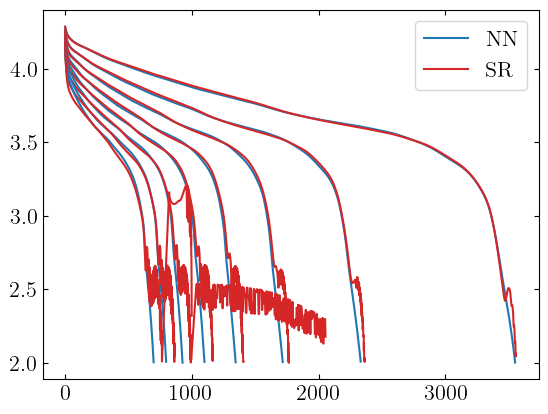

In [218]:

for j,C_rate in enumerate(np.arange(1, 5, 0.5)):
    if j == 0:
        label_NN = 'NN'
        label_SR = 'SR'
    else:        
        label_NN = None
        label_SR = None
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, NN = True, mode = 'DC')
    plt.plot(t, V_B, label=label_NN, color = COLORS[0])
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, NN = False, mode = 'DC')
    plt.plot(t, V_B, label=label_SR, color = COLORS[1])
#plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
plt.legend()

plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')


tensor([ 0.0000,  4.9782,  4.9782,  ..., -4.9782, -4.9782, -4.9782])
Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'back_in_black', 'style_F': 'static'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
s constrained to [0.0, 0.5] 1e-5 m  (static sNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


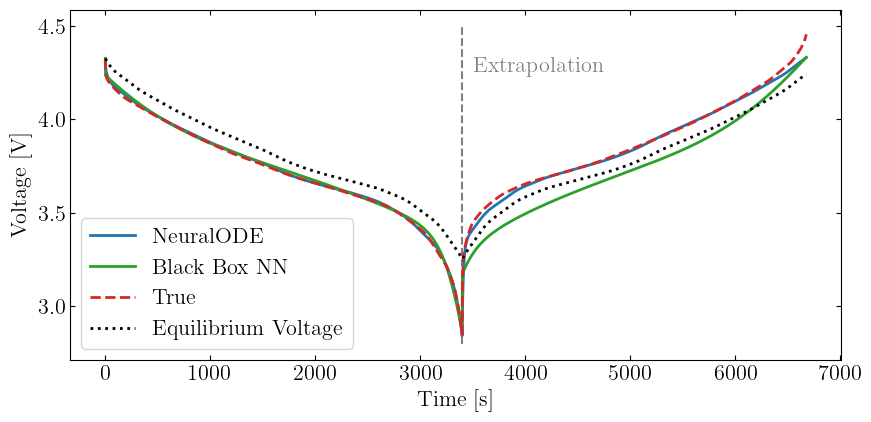

In [310]:
charge_test_df = pd.read_csv('data_discharge_charge.txt', sep=';')
I = charge_test_df['I'].values
t = charge_test_df['t'].values
charge_traj = prepare_pulse_data(charge_test_df)
print(charge_traj[0]['I_seq'])
tmax = t[-1]
C = .5;u = 10

model_name_bl = '0513_1625_b4_combo_V-back_in_black_F-static_R0c_C1c_7.19min_16h_2500eps.pt'
BLACK_MODEL, ckpt = load_nn_model(model_name_bl)
history, CONFIG_BLACK, N_HIDDEN, EPOCHS = load_checkpoint(ckpt)


V_BBB = predict_np(BLACK_MODEL, CONFIG_BLACK, charge_traj[0], V_mode = 'back_in_black')['V']

# extract t with lowest soc 
tmin_soc = t[np.argmin(charge_traj[0]['soc'])]

V_B,soc,Ue,i,t_ = ECM_solve_du(u,C, discharge = True, mode = 'DC', NN = True, tmax = tmax+1, I_profile = I)
f, ax = plt.subplots(figsize=(9,4.5))
ax.vlines(tmin_soc, ymin=2.8, ymax=4.5, color = 'gray', ls = '--')
ax.text(tmin_soc+100, 4.25, 'Extrapolation', color = 'gray')
#ax.text(tmin_soc-165, 0, 4.25, 'Training Domain', color = 'gray')
#ax2 = ax.twinx()
#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
ax.plot(t_, V_B, label='NeuralODE',lw = 2) 
ax.plot(t, V_BBB, label='Black Box NN', color = 'tab:green', ls = '-',lw = 2) 
ax.plot(t, charge_test_df['V'], label='True', color = 'tab:red', ls = '--' ,lw = 2)
ax.plot(t_,Ue, 'black', ls = ':',label='Equilibrium Voltage',lw = 2)
ax.set_xlabel('Time [s]')
#ax2.plot(t, soc, color = 'tab:red', label='SOC')
ax.set_ylabel('Voltage [V]')
ax.legend()
plt.tight_layout()
plt.savefig('Full_cycle_comp.pdf')

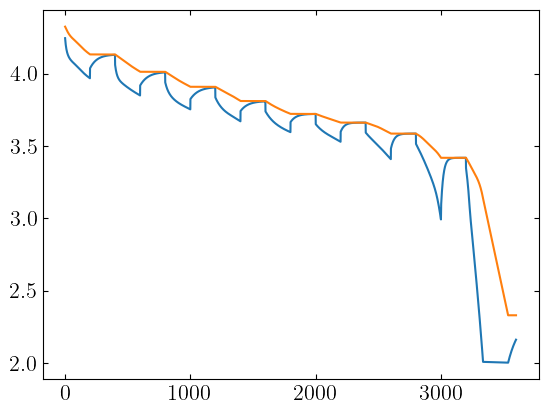

In [220]:
V_B,soc,Ue,i,t = ECM_solve_du(1,2, discharge = True, mode = 'pulse', NN = True)
f, ax = plt.subplots()

#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(t, Ue, label='Battery Voltage') 

#plt.plot(t, soc, label=f'C={C_rate}x')

In [221]:
df_true = read_data('combo_other_half', symbolic=False)
display(df_true.head())
split_train = int(df_true['trajectory'].max() * 0.8)

df_test = df_true[df_true['trajectory'] >= split_train]
df_train = df_true[df_true['trajectory'] < split_train]

print(f'F_max in test set: {df_true["F"][df_true['t'] == 0].max():.2f} ') 

#df_test_DC = df_test[df_test['pulse'] == False]
#df_train_DC = df_train[df_train['pulse'] == False]
df_dc = df_train[df_train['pulse'] == False]

,u_par,C,t,V,F,u,Ue,soc,I,eta,pulse,trajectory
0,27.9,2.75,0,4.215052,0.131997,-4.010137,4.324995,0.999998,13.690093,0.109944,False,1
1,27.9,2.75,1,4.180852,0.132017,-4.010137,4.322674,0.999236,13.690093,0.141822,False,1
2,27.9,2.75,2,4.162011,0.132030,-4.010137,4.320348,0.998472,13.690093,0.158337,False,1
3,27.9,2.75,3,4.153260,0.132042,-4.010137,4.318022,0.997708,13.690093,0.164762,False,1
4,27.9,2.75,4,4.146008,0.132055,-4.010137,4.315696,0.996944,13.690093,0.169687,False,1


F_max in test set: 0.15 


Trajectories in test set: 
[  1   3   5   9  11  13  15  17  19  21  23  27  35  37  39  43  45  51
  53  59  63  69  71  75  77  79  83  85  89  91  95  97 103 105 107 109
 111 113 117 121 125 127 133 135 139 141 147 151 153 159 161 163 165 167]
27
Selected trajectory: 27 with C=1.49 and u_par=0.0
9
Selected trajectory: 9 with C=4.01 and u_par=0.0


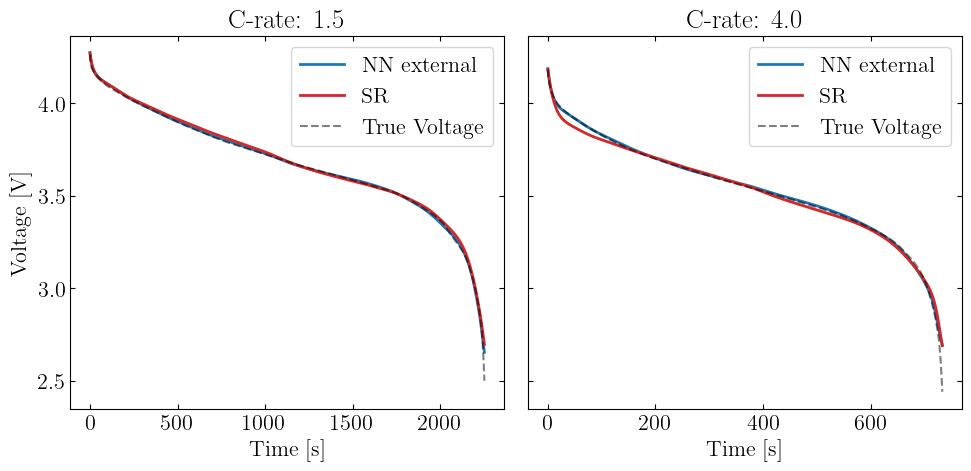

In [237]:


#plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

print(f'Trajectories in test set: ')


df = df_dc
print(df['trajectory'].unique())
trajs = prepare_data(df)
u_C_pairs = df.loc[df['t'] == 0, ['u_par', 'C', 'trajectory']]

f,ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

for j,C in enumerate([1.5, 4.]):

    traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) 
    print(traj)
    C_ext = trajs[traj]['C']
    u_par_ext = trajs[traj]['u_per']
    soc_init = trajs[traj]['soc'][0]
    print(f"Selected trajectory: {traj} with C={C_ext} and u_par={u_par_ext}")
    # C_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'C'].values[0]
    # u_par_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'u_par'].values[0]
    # i= df_test.loc[df_test['trajectory'] == traj, 'I'].values
    #print(len(i))
    #ax[j].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'V'], label='True Voltage', color = 'k', ls = '--')
    #tmax = df_test.loc[df_test['trajectory'] == traj, 't'].max()
    #print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext} tmax = {tmax:.2f}s")
    
    #V_B,soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', tmax = df_test.loc[df_test['trajectory'] == traj, 't'].max()+1, I_profile = i)
    #ax[j].plot(soc, V_B, label='SR Voltage')
    traj_full = trajs[traj]
    t_max = traj_full['T']
    t_traj = np.arange(0, t_max, DT)
    #V_B, soc = NN_prediction(traj_full)

    i = traj_full['I'] * np.ones_like(t_traj)

    V_B,soc,Ue,i,t= ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = True, tmax =t_max, I_profile = i, soc_init = soc_init)


    ax[j].plot(t, V_B, label='NN external', lw = 2, color = COLORS[0])


    V_B,soc,Ue,i,t= ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = False, tmax =t_max, I_profile = i, soc_init = soc_init)

    ax[j].plot(t, V_B, label='SR', lw = 2, color = COLORS[1])
    ax[j].plot(t_traj,traj_full['V'], label='True Voltage', color = 'k', ls = '--', alpha = .5)


#    V_B_fix,t= parameter_estimation_curvefit(traj_full)
#    ax[j].plot(V_B_fix, label='Fix ECM')
#plt.plot(t, Ue, label='Equilibrium Potential', color = 'k', ls = '--')

#VB_fix, t = parameter_estimation_curvefit(df_true.loc[df_true['trajectory'] == traj])
#plt.plot(t, VB_fix, label='Curvefit ECM')
#plt.plot(t[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], V_B[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], label='NN Voltage')
    ax[j].set_xlabel('Time [s]')
    ax[j].set_title(f'C-rate: {C_ext:.1f}')
    ax[j].legend()
ax[0].set_ylabel('Voltage [V]')

# ax[2].plot(t,soc, label='SOC', color = 'tab:red')
# ax[2].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'soc'], label='True Voltage', color = 'k', ls = '--')
plt.tight_layout()
plt.savefig('ecm_fit.pdf')

Trajectories in test set: 
[  1   3   5   9  11  13  15  17  19  21  23  27  35  37  39  43  45  51
  53  59  63  69  71  75  77  79  83  85  89  91  95  97 103 105 107 109
 111 113 117 121 125 127 133 135 139 141 147 151 153 159 161 163 165 167]
31
Selected trajectory: 31 with C=1.01 and u_par=17.6
Predicting k with NN
22
Selected trajectory: 22 with C=4.98 and u_par=22.9
Predicting k with NN


IndexError: index 2 is out of bounds for axis 0 with size 2

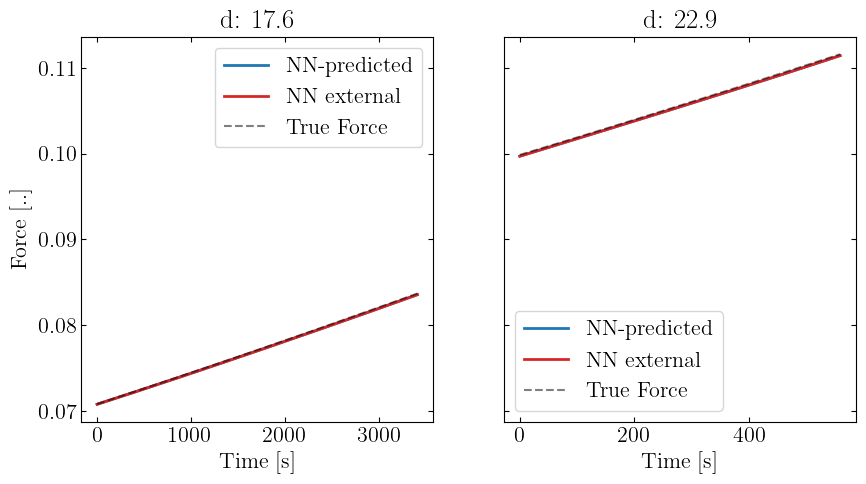

In [243]:

print(f'Trajectories in test set: ')
df = df_dc
print(df['trajectory'].unique())
trajs = prepare_data(df)
u_C_pairs = df.loc[df['t'] == 0, ['u_par', 'C', 'trajectory']]

f,ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

for j,C in enumerate([1, 30]):

    traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) 
    print(traj)
    C_ext = trajs[traj]['C']
    u_par_ext = trajs[traj]['u_per']
    soc_init = trajs[traj]['soc'][0]
    print(f"Selected trajectory: {traj} with C={C_ext} and u_par={u_par_ext}")

    traj_full = trajs[traj]
    t_max = traj_full['T']
    t_traj = np.arange(0, t_max, DT)
    F_nn, soc, s_nn = NN_prediction_F(traj_full)


    ax[j].plot(t_traj, F_nn, label='NN-predicted', lw = 2, color = COLORS[0])
    i = traj_full['I'] * np.ones_like(t_traj)

    F, s, soc, i, t = EMM_solve_ds(u_par_ext, C_ext, discharge = True, mode = 'DC', NN = True, tmax =t_max, I_profile = i, soc_init = soc_init)


    ax[j].plot(t, F, label='NN external', lw = 2, color = COLORS[1])


    # V_B,soc,Ue,i,t= EMM_solve_ds(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = False, tmax =t_max, I_profile = i, soc_init = soc_init)

    # ax[j].plot(t, F, label='SR', lw = 2, color = COLORS[2])
    ax[j].plot(t_traj,traj_full['F'], label='True Force', color = 'k', ls = '--', alpha = .5)
    ax[j].set_xlabel('Time [s]')
    ax[j].set_title(f'd: {u_par_ext:.1f}')
    ax[j].legend()
ax[0].set_ylabel('Force [..]')

ax[2].plot(t, soc, label='SOC', color = 'tab:red')
ax[2].plot(traj_full['t'], traj_full['soc'], label='True SOC', color = 'k', ls = '--')
#ax[2].plot(t, s_nn, label=r'NN-predicted $s$', color = 'tab:blue')
#ax[2].plot(t, s, label=r'NN external $s$', color = 'tab:red')
ax[2].legend()
# ax[2].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'soc'], label='True Voltage', color = 'k', ls = '--')
plt.tight_layout()
# plt.savefig('ecm_fit.pdf')

In [224]:
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)

COLORS = plot_settings.colors()

import_reload()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *

[27.9 17.5 29.9  9.5 23.   1.7  4.2  8.9  0.   0.  14.8  6.1 13.   0.
 16.4 26.5  7.3 15.9  0.  13.7  0.  11.3 22.9 14.7 18.4  4.9 27.1  0.
 29.2  1.  18.9 17.6 28.7  8.1 25.9  2.4  0.  14.  21.5 23.9  0.   0.
  3.   0.  19.6  0.  26.9 16.   0.   4.2  0.  11.8  0.6  4.8]
Predicting k with NN


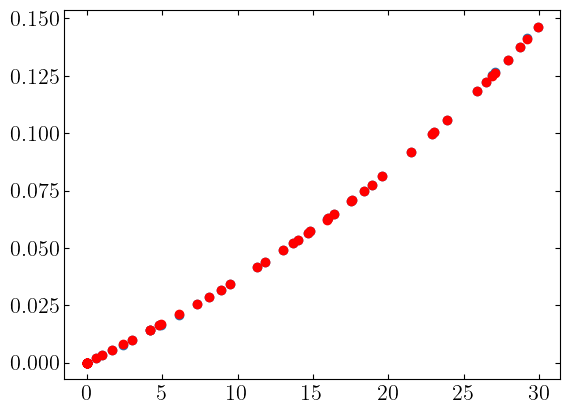

In [225]:
# extract for force 
import_reload()
df = df_dc
trajs = prepare_data(df)
F_first = df.loc[df['t'] == 0, 'F'].values
u_par_first = df.loc[df['t'] == 0, 'u_par'].values
soc_first = df.loc[df['t'] == 0, 'soc'].values
print(u_par_first)

plt.plot(u_par_first, F_first, 'o')
plt.plot(u_par_first,k_nn(1,u_par_first, 1)*u_par_first * L0/100,'ro')

Number of trajectories in pulse dataset before filtering: 75
75
Number of trajsectories in pulse dataset: 75
Selected trajectory index: 40
Selected trajectory parameters: C=2.0, u_par=7.5 tmax = 12.00s
Number of trajsectories in pulse dataset: 75
Selected trajectory index: 71
Selected trajectory parameters: C=4.0, u_par=9.9 tmax = 12.00s


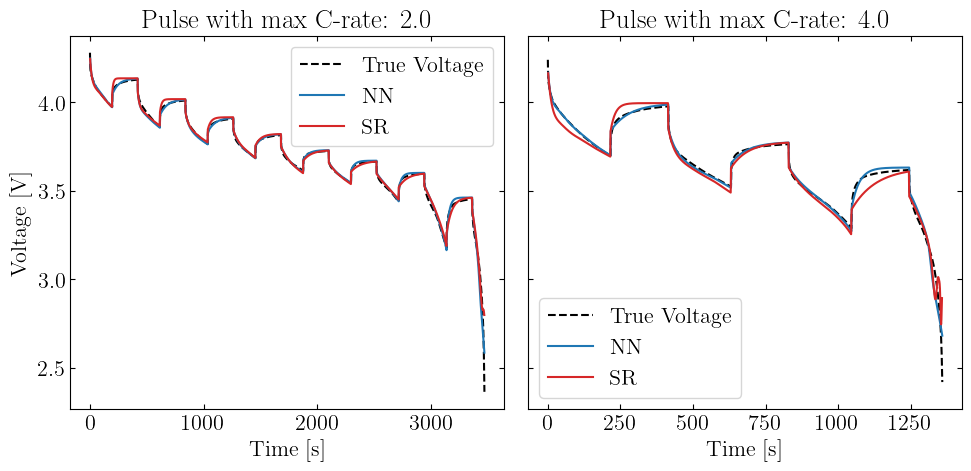

In [245]:
df_pulse = read_data('merged_pulse_hyper', symbolic=False)
#split_pulse = int(df_pulse['trajectory'].max() * 0.8)
#df_pulse_train = df_pulse[df_pulse['trajectory'] < split_pulse]

print(f"Number of trajectories in pulse dataset before filtering: {df_pulse['trajectory'].nunique()}")
#df_pulse = df_pulse[df_pulse['trajectory'] >= int(split_pulse * 0.8)]

print(len(df_pulse['trajectory'].unique()))

uc_pulse_pairs = df_pulse.loc[df_pulse['t'] == 0, ['u_par', 'C', 'trajectory']]
trajs_pulse = prepare_pulse_data(df_pulse)

C = 3.5; u = 9.9
f,ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

for j,C in enumerate([2., 4.]):

    traj = int(np.argmin(np.abs(uc_pulse_pairs['C'] - C))) 
    print(f'Number of trajsectories in pulse dataset: {df_pulse["trajectory"].nunique()}')
    C_ext = uc_pulse_pairs.loc[uc_pulse_pairs['trajectory'] == traj, 'C'].values[0]
    u_par_ext = uc_pulse_pairs.loc[uc_pulse_pairs['trajectory'] == traj, 'u_par'].values[0]
    i = df_pulse.loc[df_pulse['trajectory'] == traj, 'I'].values

    print(f"Selected trajectory index: {traj}")

    traj_full = trajs_pulse[traj]
    #ax[0].plot(df_pulse.loc[df_pulse['trajectory'] == traj, 't'], df_pulse.loc[df_pulse['trajectory'] == traj, 'V'], label='True Voltage', color = 'k', ls = '--')
    ax[j].plot(traj_full['t'], traj_full['V'], label='True Voltage', color = 'k', ls = '--')
    tmax = len(traj_full)#df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max()
    print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext} tmax = {tmax:.2f}s")
    #VB, soc = NN_prediction(trajs_pulse[traj])
    #ax[0].plot(traj_full['t'], VB, label='NN-pred')
    VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max()+1, I_profile = i, NN = True)
    ax[j].plot(t, VB, label='NN', color = COLORS[0])
    VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max(), I_profile = i, NN = False)
    ax[j].plot(t, VB, label='SR', color = COLORS[1])
    #VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'pulse', NN = True, tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max())
    #plt.plot(t, VB, label='NN Voltage')
    #R1 = R1(np.abs(C_ext), u_par_ext/100, soc, NN = True)
    #ax[1].plot(t, R1, label='R1', color = 'tab:blue')
    ax[j].legend()
    #ax[1].plot(t, soc, label='Current Profile', color = 'tab:red')
    #ax[1].plot(df_pulse.loc[df_pulse['trajectory'] == traj, 't'], df_pulse.loc[df_pulse['trajectory'] == traj, 'soc'], label='Current Profile', color = 'black', ls = '--')
    #VB_fix, soc = parameter_estimation_curvefit(df_pulse.loc[df_pulse['trajectory'] == traj])
    #ax[0].plot(t, VB_fix, label='Fix ECM', color = 'tab:green')
    ax[j].set_title(f'Pulse with max C-rate: {C_ext:.1f}')
    ax[j].set_xlabel('Time [s]')
ax[0].set_ylabel('Voltage [V]')
plt.tight_layout()
plt.savefig('ecm_pulse_fit.pdf')

In [227]:
def scale(df = df_true, variables = ['V','F']):
    scaled_df = df.copy()
    range_val = {}
    for var in variables:
        min_val = df[var].min()
        max_val = df[var].max()
        range_val[var] = (max_val - min_val)
    return range_val


def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    #mae = np.mean(np.abs(y_true - y_pred))
    #r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return rmse

def simulate_and_evaluate(df, DC = True):
    scaling = scale()
    N = df['trajectory'].nunique()
    if DC:
        trajs = prepare_data(df)
    else:
        trajs = prepare_pulse_data(df)
    rmse_SR = np.zeros((N,2))
    rmse_NN = np.zeros((N,2))
    rmse_fix = np.zeros(N)
    obs_inpt = np.zeros((N,2))
    V_true_all = []
    F_true_all = []
    V_pred_SR_all = []
    F_pred_SR_all = []
    V_pred_NN_all = [] 
    F_pred_NN_all = []
    V_pred_fix_all = []
    for i in range(N):
        if 'I_seq' in trajs[i].keys():
            trajs[i]['I'] = trajs[i]['I_seq']
        V_true = trajs[i]['V'].numpy()
        F_true = trajs[i]['F'].numpy()
        try:
            C = max(trajs[i]['I'].numpy()) * 3600 / Q0
            I = trajs[i]['I'].numpy()
        except:
            C = trajs[i]['I'] * 3600 / Q0
            if DC:
                I = trajs[i]['I'] * np.ones(len(V_true) +1)
            else:
                I = trajs[i]['I'].numpy()
        
        try:
            u_par = trajs[i]['u_per'].numpy()
        except:
            u_par = trajs[i]['u_per']
        #print(f"Evaluating trajectory {traj} with {len(V_true)} data points.")
        obs_inpt[i,0] = C
        obs_inpt[i,1] = u_par

        if DC: 
            lent = len(V_true) + 1
        else:
            lent = len(V_true)
        V_B_NN,_,_,_,_ = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = True, tmax=lent ,I_profile =I)
        V_B, _,_,_,_ = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = False, tmax=lent, I_profile = I) 
        V_B_fix,_ = parameter_estimation_curvefit(trajs[i], DC = DC)
        n = min(len(V_true), len(V_B), len(V_B_NN), len(V_B_fix))
        #V_true = V_true[:n]


        V_B = V_B[:n]


        V_B_NN = V_B_NN[:n]

        V_true = V_true[:n]

        V_B_fix = V_B_fix[:n]

        #print(f'lengths: V_true={len(V_true)}, F_true={len(F_true)}, V_B={len(V_B)}, F={len(F)}, V_B_NN={len(V_B_NN)}, F_NN={len(F_NN)}')
        # Y_true = np.concatenate((V_true, F_true))
        # Y_pred_NN = np.concatenate((V_B_NN, F_NN))
        # Y_pred = np.concatenate((V_B, F))  
        rmse_fix[i] = metrics(V_true, V_B_fix) / scaling['V']
        rmse_SR[i,0] = metrics(V_true, V_B) / scaling['V']
        rmse_NN[i,0] = metrics(V_true, V_B_NN) / scaling['V']
        print(f'Trajectory {i}, C-rate: {C:.2f}, u_par: {u_par:.2f}, V_B={rmse_SR[i]}, V_B_NN={rmse_NN[i]}, V_B_fix={rmse_fix[i]}')
        V_true_all.append(V_true)
        F_true_all.append(F_true)
        V_pred_SR_all.append(V_B)
        V_pred_NN_all.append(V_B_NN)
        V_pred_fix_all.append(V_B_fix)
    return rmse_SR, rmse_NN, rmse_fix, obs_inpt, V_true_all,  V_pred_SR_all,  V_pred_NN_all, V_pred_fix_all

In [228]:
df_p = read_data('merged_pulse_hyper', symbolic=False)
df_ = df_p[df_p['trajectory'] >= int(0.8 * df_p['trajectory'].max())]
print(f"Evaluating on {df_['trajectory'].nunique()} trajectories in pulse dataset.")

df_ = df_true[df_true['pulse'] == True]

nrmse_SR, nrmse_NN, nrmse_fix, obs_inpt, V_true, V_pred_SR, V_pred_NN, V_pred_fix = simulate_and_evaluate(df_, DC = False)

Evaluating on 16 trajectories in pulse dataset.
Trajectory 0, C-rate: 3.90, u_par: 28.30, V_B=[0.02133984 0.        ], V_B_NN=[0.01099439 0.        ], V_B_fix=0.03741828487894793
Trajectory 1, C-rate: 2.30, u_par: 9.70, V_B=[0.01232694 0.        ], V_B_NN=[0.00969581 0.        ], V_B_fix=0.026334477340327397
Trajectory 2, C-rate: 3.86, u_par: 0.00, V_B=[0.01713987 0.        ], V_B_NN=[0.01165367 0.        ], V_B_fix=0.03172526170826551
Trajectory 3, C-rate: 3.30, u_par: 28.10, V_B=[0.01709254 0.        ], V_B_NN=[0.01293561 0.        ], V_B_fix=0.028949816429949062
Trajectory 4, C-rate: 4.10, u_par: 2.60, V_B=[0.02273339 0.        ], V_B_NN=[0.01356446 0.        ], V_B_fix=0.03161651728231934
Trajectory 5, C-rate: 1.60, u_par: 0.00, V_B=[0.00731427 0.        ], V_B_NN=[0.00788888 0.        ], V_B_fix=0.023012768142730584


KeyboardInterrupt: 

In [ ]:
# Run ones for pulse and ones for DC, then plot

def input_map_from_rmse(obs_cc=None, rmse_cc=None,
                        obs_pulse=None, rmse_pulse=None,
                        observable='V', title=None):
    """
    Single-panel RMSE map from precomputed RMSE arrays.

    Parameters
    ----------
    obs_cc, obs_pulse : (N, 2) arrays, columns [C-rate, u_par]. Pass None to skip.
    rmse_cc, rmse_pulse : (N,) or (N, 2) NRMSE arrays. If 2D, `observable`
        picks the column (V=0, F=1).
    observable : 'V' or 'F'
    title : optional axis title
    """
    import matplotlib.colors as colors
    from matplotlib.lines import Line2D

    if observable == 'V':
        col, cbar_label = 0, r'NRMSE for $V_B$'
    elif observable == 'F':
        col, cbar_label = 1, r'NRMSE for $F$'
    else:
        raise ValueError(f"observable must be 'V' or 'F', got {observable!r}")

    def pick(rmse):
        if rmse is None:
            return None
        return rmse[:, col] if rmse.ndim == 2 else rmse

    r_cc, r_p = pick(rmse_cc), pick(rmse_pulse)

    fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

    # full domain box
    domain = [[0.5, 5], [0, 30]]
    ax.vlines(domain[0][0], domain[1][0], domain[1][1], color='gray', linestyle='--')
    ax.vlines(domain[0][1], domain[1][0], domain[1][1], color='gray', linestyle='--')
    ax.hlines(domain[1][0], domain[0][0], domain[0][1], color='gray', linestyle='--')
    ax.hlines(domain[1][1], domain[0][0], domain[0][1], color='gray', linestyle='--')
    ax.fill_between([domain[0][0], domain[0][1]],
                    domain[1][0], domain[1][1], color='gray', alpha=0.1)

    ax.set_xlabel('C-rate [a.u.]')
    ax.set_ylabel(r'$\widetilde{d}$ [a.u.]')

    cmap_V, cmap_F = custom_cmap()
    cmap = cmap_V if observable == 'V' else cmap_F

    # shared norm across whatever was provided
    all_r = np.concatenate([r for r in (r_cc, r_p) if r is not None])
    norm = colors.Normalize(vmin=all_r.min(), vmax=all_r.max())

    sc = None
    if obs_cc is not None and r_cc is not None:
        sc = ax.scatter(obs_cc[:, 0], obs_cc[:, 1],
                        c=r_cc, cmap=cmap, norm=norm, marker='o')
    if obs_pulse is not None and r_p is not None:
        sc = ax.scatter(obs_pulse[:, 0], obs_pulse[:, 1],
                        c=r_p, cmap=cmap, norm=norm, marker='x')

    fig.colorbar(sc, ax=ax, label=cbar_label)

    handles = []
    if obs_cc is not None:
        handles.append(Line2D([0], [0], marker='o', color='gray',
                              linestyle='', label='CC'))
    if obs_pulse is not None:
        handles.append(Line2D([0], [0], marker='x', color='gray',
                              linestyle='', label='Pulse'))
    if handles:
        ax.legend(handles=handles, loc='best', frameon=True)

    if title:
        ax.set_title(title)

    return fig, ax

Trajectory 0, C-rate: 2.75, u_par: 27.90, V_B=[0.02244589 0.        ], V_B_NN=[0.00958431 0.        ], V_B_fix=0.04984506233620533
Trajectory 1, C-rate: 2.12, u_par: 17.50, V_B=[0.01125454 0.        ], V_B_NN=[0.00470829 0.        ], V_B_fix=0.041464991304102944
Trajectory 2, C-rate: 1.60, u_par: 29.90, V_B=[0.01083143 0.        ], V_B_NN=[0.0048429 0.       ], V_B_fix=0.036780969764471816
Trajectory 3, C-rate: 0.61, u_par: 9.50, V_B=[0.01196477 0.        ], V_B_NN=[0.00556802 0.        ], V_B_fix=0.02767680374571856
Trajectory 4, C-rate: 4.97, u_par: 23.00, V_B=[0.0867308 0.       ], V_B_NN=[0.01031292 0.        ], V_B_fix=0.04918898283302869
Trajectory 5, C-rate: 2.66, u_par: 1.70, V_B=[0.01333411 0.        ], V_B_NN=[0.00488821 0.        ], V_B_fix=0.04330865173671637
Trajectory 6, C-rate: 1.41, u_par: 4.20, V_B=[0.01247558 0.        ], V_B_NN=[0.00638834 0.        ], V_B_fix=0.03804644570226478
Trajectory 7, C-rate: 3.71, u_par: 8.90, V_B=[0.03296649 0.        ], V_B_NN=[0.00911815

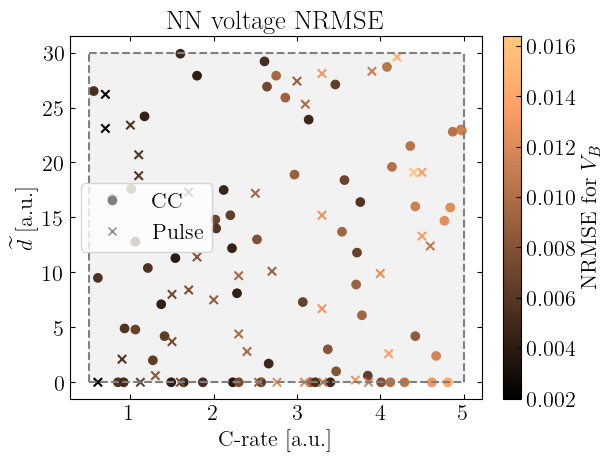

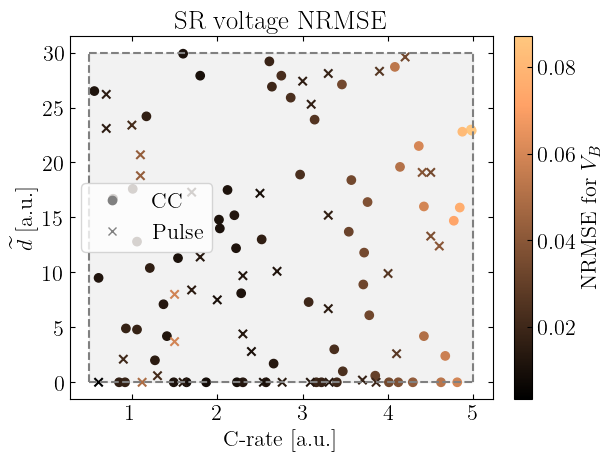

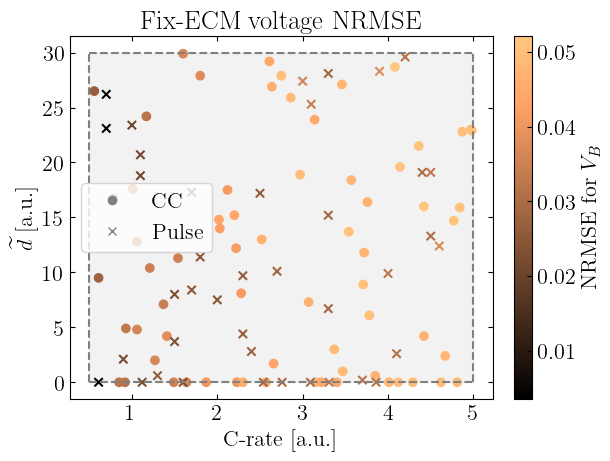

In [ ]:
df_true = read_data('combo_other_half', symbolic=False)

# CC evaluation On full combo other half
df_cc_test = df_true[df_true['pulse'] == False]
rmse_SR_cc, rmse_NN_cc, rmse_fix_cc, obs_cc, *_ = simulate_and_evaluate(df_cc_test, DC=True)

# Pulse evaluation
df_p_test = df_true[df_true['pulse'] == True]
print(f"Evaluating on {df_p_test['trajectory'].nunique()} pulse trajectories.")
rmse_SR_p, rmse_NN_p, rmse_fix_p, obs_p, *_ = simulate_and_evaluate(df_p_test, DC=False)


In [ ]:
# Plot — NN, voltage
fig, ax = input_map_from_rmse(
    obs_cc=obs_cc,  rmse_cc=rmse_NN_cc,
    obs_pulse=obs_p, rmse_pulse=rmse_NN_p,
    observable='V', title='NN voltage NRMSE',
)

# Plot — SR, voltage
fig, ax = input_map_from_rmse(
    obs_cc=obs_cc,  rmse_cc=rmse_SR_cc,
    obs_pulse=obs_p, rmse_pulse=rmse_SR_p,
    observable='V', title='SR voltage NRMSE',
)

# Plot — Fix ECM (1D arrays, no force, so observable must be 'V')
fig, ax = input_map_from_rmse(
    obs_cc=obs_cc,  rmse_cc=rmse_fix_cc,
    obs_pulse=obs_p, rmse_pulse=rmse_fix_p,
    observable='V', title='Fix-ECM voltage NRMSE',
)

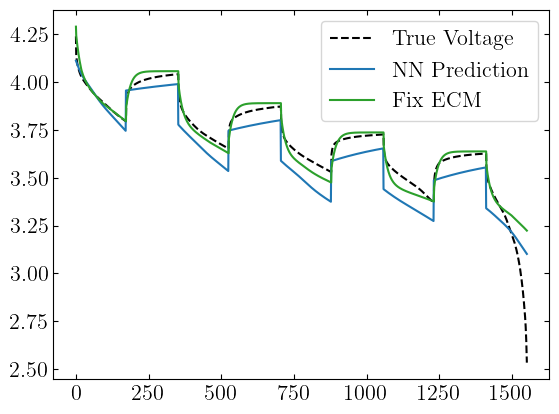

In [ ]:
l = 60
plt.plot(V_true[l], label='True Voltage', color = 'k', ls = '--')
#plt.plot(V_pred_SR[l], label='SR Prediction', color = COLORS[1])
plt.plot(V_pred_NN[l], label='NN Prediction', color = COLORS[0])
plt.plot(V_pred_fix[l], label='Fix ECM', color = 'tab:green')
plt.legend()

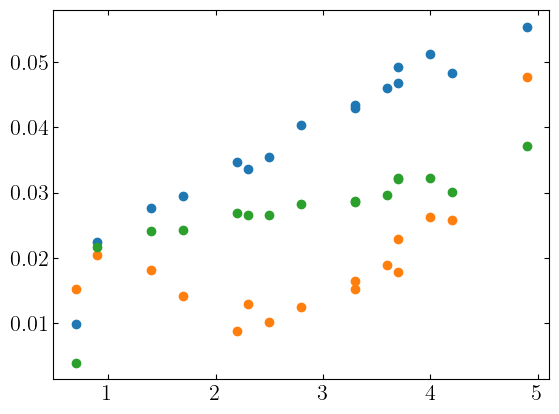

In [ ]:
plt.scatter(obs_inpt[:,0], nrmse_NN[:,0])
plt.scatter(obs_inpt[:,0], nrmse_SR[:,0])
plt.scatter(obs_inpt[:,0], nrmse_fix[:])

In [ ]:
avg_Nrmse_NN_V = np.mean(nrmse_NN[:,0])
avg_Nrmse_NN_F = np.mean(nrmse_NN[:,1])
avg_Nrmse_SR_V = np.mean(nrmse_SR[:,0])
avg_Nrmse_SR_F = np.mean(nrmse_SR[:,1])
avg_Nrmse_fix_V = np.mean(nrmse_fix)
nrmse_fix_V = np.vstack((nrmse_fix, np.zeros_like(nrmse_fix))).T   



print(nrmse_fix_V.shape, nrmse_NN.shape, nrmse_SR.shape)

(16, 2) (16, 2) (16, 2)


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_46645/30164577.py:44: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax[j].set_ylim(0, max(vals) * 1.2)


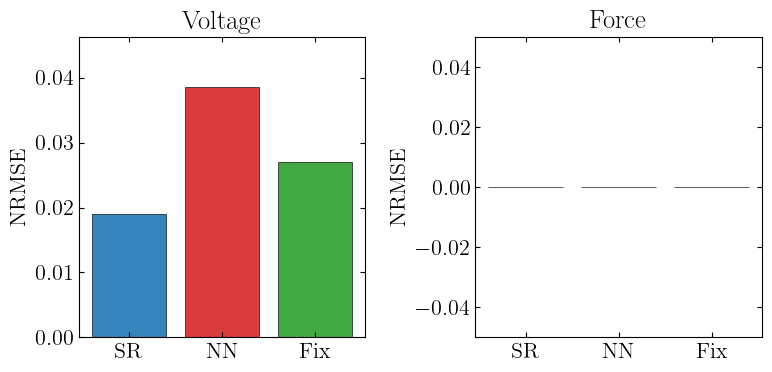

In [ ]:
metric_names = ['Voltage', 'Force']
methods = ['SR', 'NN', 'Fix']

bar_plot_dict = {
    'NN Voltage': avg_Nrmse_NN_V,
    'NN Force': avg_Nrmse_NN_F,
    'SR Voltage': avg_Nrmse_SR_V,
    'SR Force': avg_Nrmse_SR_F,
    'Fix Voltage': avg_Nrmse_fix_V,
    'Fix Force': np.zeros_like(avg_Nrmse_fix_V)
}

n_methods = len(methods)
n_metrics = len(metric_names)

fig, ax = plt.subplots(
    1,
    n_metrics,
    figsize=(4 * n_metrics, 4),
    sharey=False
)

# Handle single subplot case
if n_metrics == 1:
    ax = [ax]

for j, metric in enumerate(metric_names):

    # Collect values dynamically from dictionary
    vals = []

    for method in methods:
        key = f'{method} {metric}'
        vals.append(np.mean(bar_plot_dict[key]))

    bars = ax[j].bar(
        methods,
        vals,
        color=[COLORS[i % len(COLORS)] for i in range(n_methods)], alpha = 0.9, edgecolor='black', linewidth=.5
    )

    ax[j].set_title(metric)
    ax[j].set_ylabel('NRMSE')
    ax[j].set_ylim(0, max(vals) * 1.2)
    # add error bars for min and max in the rmse values across trajectories

    # ax[j].errorbar(
    #     methods,
    #     vals,
    #     yerr=[np.min(vals), np.max(vals)],
    #     fmt='none',
    #     ecolor='black',
    #     capsize=5
    # )
    # 
    # for b in bars:
    #     h = b.get_height()
    #     ax[j].text(
    #         b.get_x() + b.get_width() / 2,
    #         h,
    #         f'{h:.3f}',
    #         ha='center',
    #         va='bottom',
    #         fontsize=9
    #     )

plt.tight_layout()
plt.show()